# cisTopic Model Analysis

Interactive notebook for exploring a **selected** topic model.

**Prerequisites:** You should have already:
1. Built a cisTopic object (`build_cistopic_obj.py`)
2. Trained models (`run_models.py`)
3. Evaluated models (`evaluate_models.py`) and chosen your topic count

Fill in the config cell below and run all cells.

## 1. Configuration

In [1]:
# ============================================================
# CONFIGURATION — Fill these in before running
# ============================================================

cistopic_obj_path = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/objects/sc-islet-differentiation_10X-Multiome_endocrine_replicate.pkl"          # Path to cisTopic .pkl from build_cistopic_obj.py
models_path = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/models_mallet/merged"                # Path to models .pkl from run_models.py (file or directory)
output_dir = "/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/evaluation"                 # Output directory for analysis results
selected_n_topics = 50           # Number of topics to use (from evaluate_models.py)
groupby_variable = "cell_type"         # Cell metadata column for grouping (e.g. "cell_type")
group_colors = None             # Optional dict of {group_name: color} for custom colors

The history saving thread hit an unexpected error (DatabaseError('database disk image is malformed')).History will not be written to the database.


## 2. Imports & Load Objects

In [2]:
import glob
import os
import pickle

import anndata as ad
import matplotlib.pyplot as plt
import pandas as pd
import scanpy as sc
import seaborn as sns

from pycisTopic.cistopic_class import CistopicObject
from pycisTopic.lda_models import evaluate_models
from pycisTopic.clust_vis import run_umap, plot_metadata, cell_topic_heatmap

# Validate config
assert cistopic_obj_path, "Set cistopic_obj_path in the config cell"
assert models_path, "Set models_path in the config cell"
assert output_dir, "Set output_dir in the config cell"
assert isinstance(selected_n_topics, int) and selected_n_topics > 0, (
    "selected_n_topics must be a positive integer"
)

os.makedirs(output_dir, exist_ok=True)
print(f"Output directory: {output_dir}")

/cellar/users/aklie/projects/igvf/single_cell_utilities/pycistopic/.venv/lib/python3.11/site-packages/pycisTopic/__init__.py:3: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import DistributionNotFound, get_distribution
/cellar/users/aklie/projects/igvf/single_cell_utilities/pycistopic/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-09 09:13:29,930	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


Output directory: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/evaluation


In [3]:
# Load cisTopic object
print(f"Loading cisTopic object from {cistopic_obj_path}")
with open(cistopic_obj_path, "rb") as f:
    cistopic_obj = pickle.load(f)
print(f"  {cistopic_obj.fragment_matrix.shape[0]} regions x {cistopic_obj.fragment_matrix.shape[1]} cells")
cistopic_obj.cell_data.head()

Loading cisTopic object from /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/objects/sc-islet-differentiation_10X-Multiome_endocrine_replicate.pkl
  234261 regions x 47898 cells


,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample_name,diff_batch,diff_stage,replicate,cell_type,single_timepoint_seurat_annotation,D4_D7_continuous_seurat_annotation,D7_D9_continuous_seurat_annotation,D9_D12_continuous_seurat_annotation,D22_D45_continuous_seurat_annotation,D15_D22_continuous_seurat_annotation,D12_D15_continuous_seurat_annotation
HZ015_D9_rep1#AACCGGCTCCTAATTC-1___sc-islet-differentiation_10X-Multiome_endocrine_replicate,4431,3.646502,4170,3.620136,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,NaN,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AAGCCTGTCATTACGA-1___sc-islet-differentiation_10X-Multiome_endocrine_replicate,12510,4.097257,11010,4.041787,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,NaN,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AAGCTATGTCTTGCAT-1___sc-islet-differentiation_10X-Multiome_endocrine_replicate,7346,3.866051,6795,3.832189,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,NaN,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AAGTCTATCGCTCACT-1___sc-islet-differentiation_10X-Multiome_endocrine_replicate,5298,3.724112,4974,3.696706,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,NaN,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AATATCCCAGGACACA-1___sc-islet-differentiation_10X-Multiome_endocrine_replicate,14635,4.165393,12631,4.101438,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,NaN,ENP,ENP,NaN,NaN,NaN


In [4]:
# Load models — handles both single .pkl (list) and directory of .pkl files
if os.path.isfile(models_path):
    print(f"Loading models from file: {models_path}")
    with open(models_path, "rb") as f:
        models = pickle.load(f)
    if not isinstance(models, list):
        models = [models]
elif os.path.isdir(models_path):
    print(f"Loading models from directory: {models_path}")
    models = []
    for pkl_file in sorted(glob.glob(os.path.join(models_path, "*.pkl"))):
        m = pickle.load(open(pkl_file, "rb"))
        if isinstance(m, list):
            models.extend(m)
        else:
            models.append(m)
else:
    raise FileNotFoundError(f"Models path not found: {models_path}")

available_topics = sorted([m.cell_topic.shape[0] for m in models])
print(f"  Loaded {len(models)} model(s) with topic counts: {available_topics}")

# Validate selected topic count exists
assert selected_n_topics in available_topics, (
    f"selected_n_topics={selected_n_topics} not found. "
    f"Available: {available_topics}"
)

Loading models from directory: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/models_mallet/merged
  Loaded 17 model(s) with topic counts: [2, 5, 10, 12, 14, 16, 18, 20, 22, 24, 26, 28, 30, 35, 40, 45, 50]


## 3. Model Evaluation Metrics

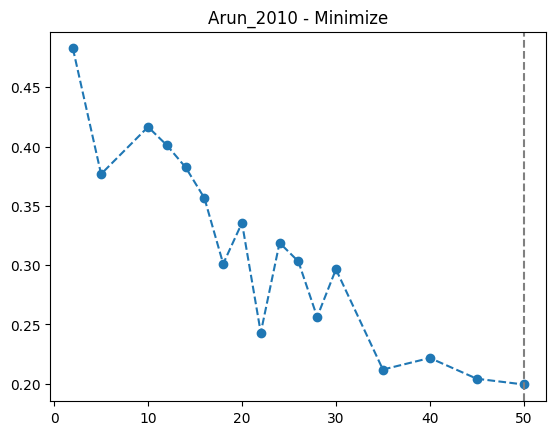

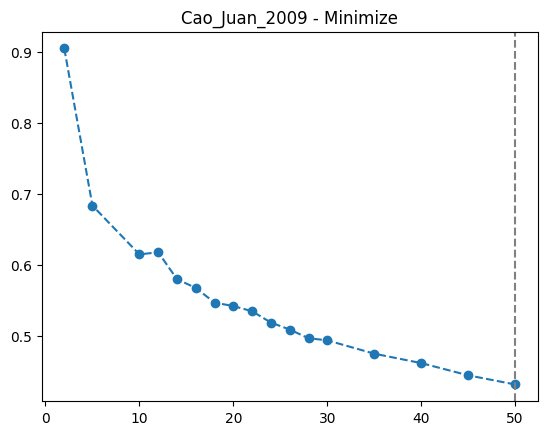

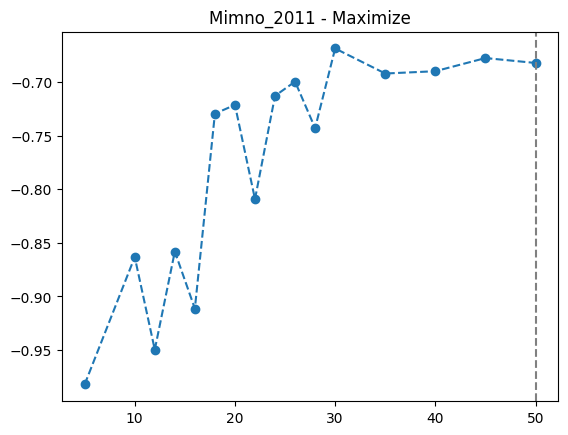

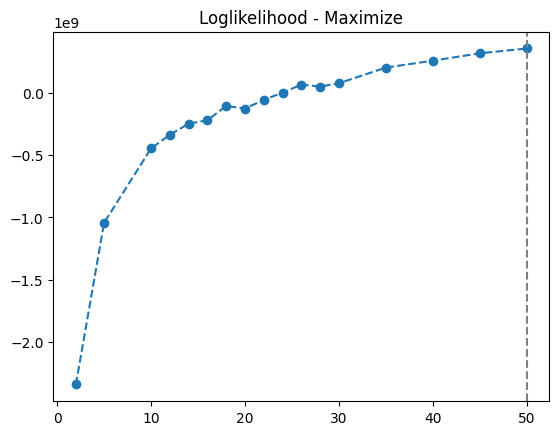

<Figure size 640x480 with 0 Axes>

In [5]:
# Plot standard evaluation metrics across all models
# Note: Minmo_2011 (coherence) can produce NaN with very few topic counts or
# sparse data. If it fails, we retry without that metric.
try:
    model = evaluate_models(
        models,
        select_model=None,
        return_model=False,
        metrics=["Arun_2010", "Cao_Juan_2009", "Minmo_2011", "loglikelihood"],
        plot_metrics=True,
        plot=False,
    )
except (ValueError, FloatingPointError):
    print("Minmo_2011 metric failed (likely too few models). Retrying without it.")
    plt.close("all")
    model = evaluate_models(
        models,
        select_model=None,
        return_model=False,
        metrics=["Arun_2010", "Cao_Juan_2009", "loglikelihood"],
        plot_metrics=True,
        plot=False,
    )
plt.savefig(
    os.path.join(output_dir, "model_evaluation_metrics.pdf"),
    bbox_inches="tight", dpi=150,
)
plt.show()

## 4. Select & Add Model to cisTopic Object

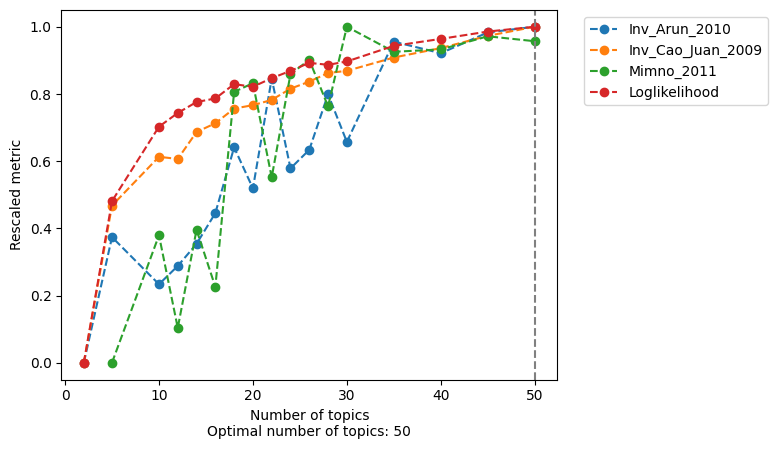

Selected model with 50 topics
Cell-topic matrix: (50, 47898) (topics x cells)


In [6]:
# Select and add the chosen model
model = evaluate_models(
    models,
    select_model=selected_n_topics,
    return_model=True,
    metrics=["Arun_2010", "Cao_Juan_2009", "Minmo_2011", "loglikelihood"],
    plot_metrics=False,
)
cistopic_obj.add_LDA_model(model)
print(f"Selected model with {selected_n_topics} topics")

# Extract cell-topic matrix for the selected model
cell_topic_df = cistopic_obj.selected_model.cell_topic.copy()
cell_topic_df.columns = (
    cell_topic_df.columns.str.split("___", expand=True).get_level_values(0)
)
print(f"Cell-topic matrix: {cell_topic_df.shape} (topics x cells)")

## 5. UMAP Visualization

In [7]:
# Run cisTopic UMAP on the selected model
run_umap(cistopic_obj, target="cell", scale=False)

# Build AnnData for scanpy-style analysis (cells x topics)
adata_topics = ad.AnnData(
    X=cell_topic_df.values.T,
    obs=pd.DataFrame(index=cell_topic_df.columns),
    var=pd.DataFrame(index=cell_topic_df.index),
)

# Add cisTopic UMAP coordinates
umap_df = cistopic_obj.projections["cell"]["UMAP"].copy()
umap_df.index = umap_df.index.str.split("___", expand=True).get_level_values(0)
adata_topics.obsm["X_umap"] = umap_df.loc[adata_topics.obs_names].values

# Add topic embedding
adata_topics.obsm["X_cisTopic"] = cell_topic_df.values.T

# Copy over cell metadata from cisTopic object
cell_data = cistopic_obj.cell_data.copy()
cell_data.index = cell_data.index.str.split("___", expand=True).get_level_values(0)
for col in cell_data.columns:
    if col in adata_topics.obs_names:
        continue
    matched = cell_data[col].reindex(adata_topics.obs_names)
    if matched.notna().any():
        adata_topics.obs[col] = matched.values

print(adata_topics)
adata_topics.obs.head()

2026-03-09 09:15:38,612 cisTopic     INFO     Running UMAP


/cellar/users/aklie/projects/igvf/single_cell_utilities/pycistopic/.venv/lib/python3.11/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


AnnData object with n_obs × n_vars = 47898 × 50
    obs: 'cisTopic_nr_frag', 'cisTopic_log_nr_frag', 'cisTopic_nr_acc', 'cisTopic_log_nr_acc', 'sample_id', 'sample_name', 'diff_batch', 'diff_stage', 'replicate', 'cell_type', 'single_timepoint_seurat_annotation', 'D7_D9_continuous_seurat_annotation', 'D9_D12_continuous_seurat_annotation', 'D22_D45_continuous_seurat_annotation', 'D15_D22_continuous_seurat_annotation', 'D12_D15_continuous_seurat_annotation'
    obsm: 'X_umap', 'X_cisTopic'


,cisTopic_nr_frag,cisTopic_log_nr_frag,cisTopic_nr_acc,cisTopic_log_nr_acc,sample_id,sample_name,diff_batch,diff_stage,replicate,cell_type,single_timepoint_seurat_annotation,D7_D9_continuous_seurat_annotation,D9_D12_continuous_seurat_annotation,D22_D45_continuous_seurat_annotation,D15_D22_continuous_seurat_annotation,D12_D15_continuous_seurat_annotation
HZ015_D9_rep1#AACCGGCTCCTAATTC-1,4431,3.646502,4170,3.620136,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AAGCCTGTCATTACGA-1,12510,4.097257,11010,4.041787,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AAGCTATGTCTTGCAT-1,7346,3.866051,6795,3.832189,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AAGTCTATCGCTCACT-1,5298,3.724112,4974,3.696706,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,ENP,ENP,NaN,NaN,NaN
HZ015_D9_rep1#AATATCCCAGGACACA-1,14635,4.165393,12631,4.101438,sc-islet-differentiation_10X-Multiome_endocrin...,HZ015_D9_rep1,HZ015,D9,rep1,early_ENP,D9_ENP,ENP,ENP,NaN,NaN,NaN


In [17]:
# REad this yaml into a dict /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/config/colors/sc-islet-differentiation_10X-Multiome.yaml
import yaml
with open("/cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/config/colors/sc-islet-differentiation_10X-Multiome.yaml") as f:
    color_config = yaml.safe_load(f)
group_colors = color_config.get("celltype_colors", None)
print(f"Using group colors: {group_colors is not None}")

Using group colors: True


In [18]:
# Validate groupby variable if set
if groupby_variable is not None:
    assert groupby_variable in adata_topics.obs.columns, (
        f"groupby_variable='{groupby_variable}' not found in cell metadata. "
        f"Available columns: {list(adata_topics.obs.columns)}"
    )
    # Apply custom colors if provided
    if group_colors is not None:
        adata_topics.obs[groupby_variable] = adata_topics.obs[groupby_variable].astype("category")
        present_colors = {k: v for k, v in group_colors.items() if k in adata_topics.obs[groupby_variable].cat.categories}
        adata_topics.obs[groupby_variable] = adata_topics.obs[groupby_variable].cat.reorder_categories(present_colors.keys())
        adata_topics.uns[f"{groupby_variable}_colors"] = list(present_colors.values())

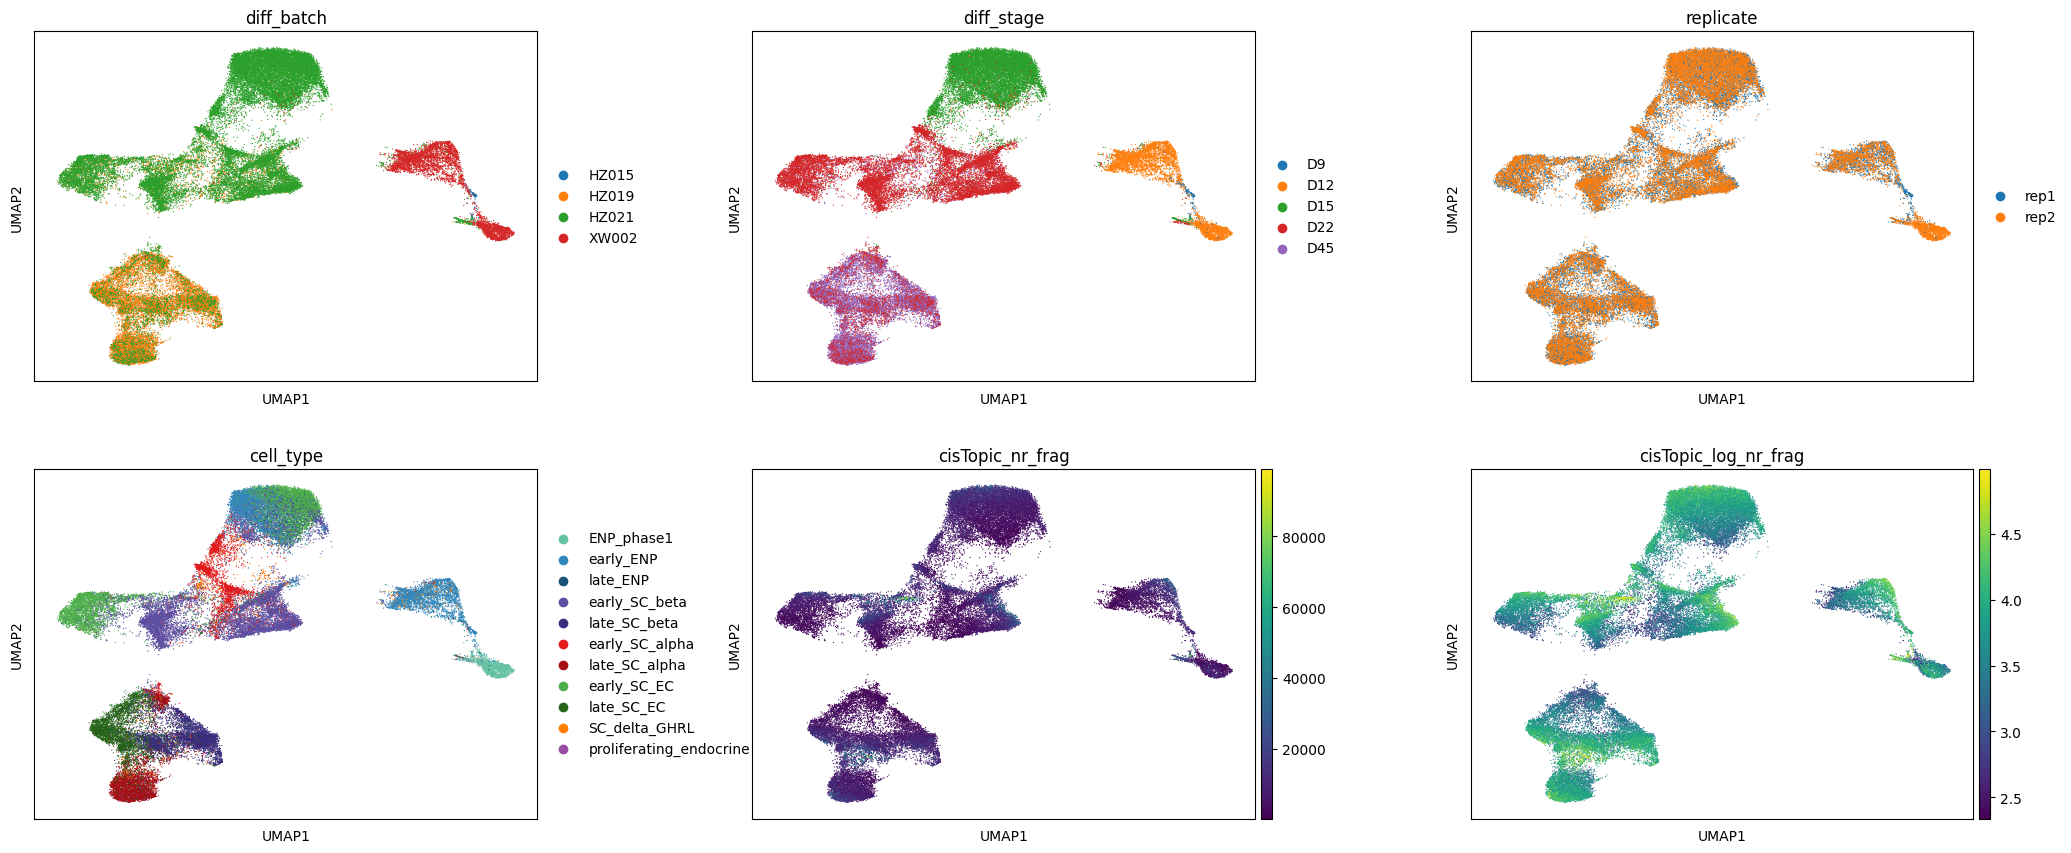

In [19]:
# Plot UMAP
plot_cols = ["diff_batch", "diff_stage", "replicate"]
if groupby_variable is not None:
    plot_cols.append(groupby_variable)
plot_cols.extend([c for c in adata_topics.obs.columns if "cisTopic" in c][:2])
if not plot_cols:
    plot_cols = [adata_topics.obs.columns[0]] if len(adata_topics.obs.columns) > 0 else []

if plot_cols:
    fig = sc.pl.umap(
        adata_topics, color=plot_cols, s=3, wspace=0.3, ncols=3,
        show=False, return_fig=True,
    )
    fig.savefig(
        os.path.join(output_dir, "umap_overview.pdf"),
        bbox_inches="tight", dpi=150,
    )
    plt.show()

## 6. Cell-Topic Heatmap

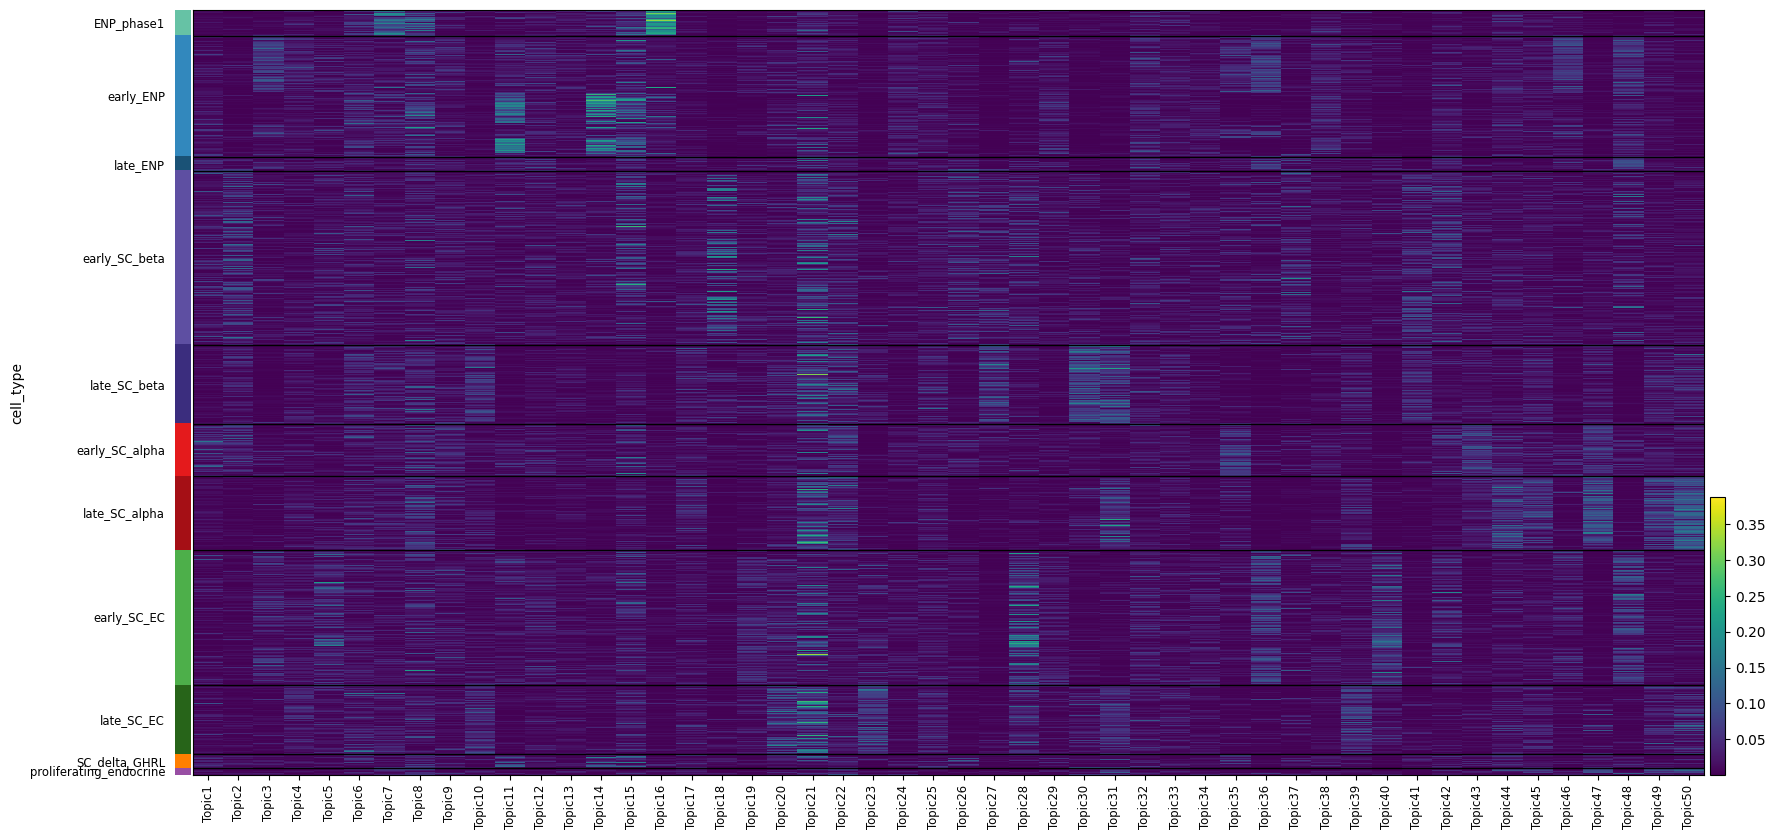

In [20]:
if groupby_variable is not None:
    ax = sc.pl.heatmap(
        adata_topics,
        var_names=adata_topics.var_names,
        groupby=groupby_variable,
        use_raw=False,
        log=False,
        figsize=(20, 10),
        cmap="viridis",
        show=False,
        show_gene_labels=True,
    )
    plt.savefig(
        os.path.join(output_dir, "cell_topic_heatmap.pdf"),
        bbox_inches="tight", dpi=150,
    )
    plt.show()
else:
    print("Set groupby_variable in the config cell to generate a grouped heatmap.")
    print("Showing ungrouped heatmap instead.")
    fig, ax = plt.subplots(figsize=(20, 10))
    sns.heatmap(adata_topics.to_df().T, cmap="viridis", ax=ax, xticklabels=False)
    ax.set_xlabel("Cells")
    ax.set_ylabel("Topics")
    plt.savefig(
        os.path.join(output_dir, "cell_topic_heatmap.pdf"),
        bbox_inches="tight", dpi=150,
    )
    plt.show()

## 7. Scanpy-Style Analysis

Build a neighbors graph from the topic embedding, run Leiden clustering, and visualize with matrix plots.

In [21]:
# Add scaled layer for visualization
adata_topics.layers["scaled"] = sc.pp.scale(adata_topics, copy=True).X

# Neighbors + Leiden clustering
sc.pp.neighbors(adata_topics, use_rep="X_cisTopic", n_neighbors=30, metric="cosine")
for res in [0.2, 0.5, 0.8, 1.0]:
    sc.tl.leiden(adata_topics, resolution=res, key_added=f"leiden_{res}")

print("Leiden clustering results added.")

/tmp/ipykernel_531129/2276616574.py:7: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_topics, resolution=res, key_added=f"leiden_{res}")


Leiden clustering results added.


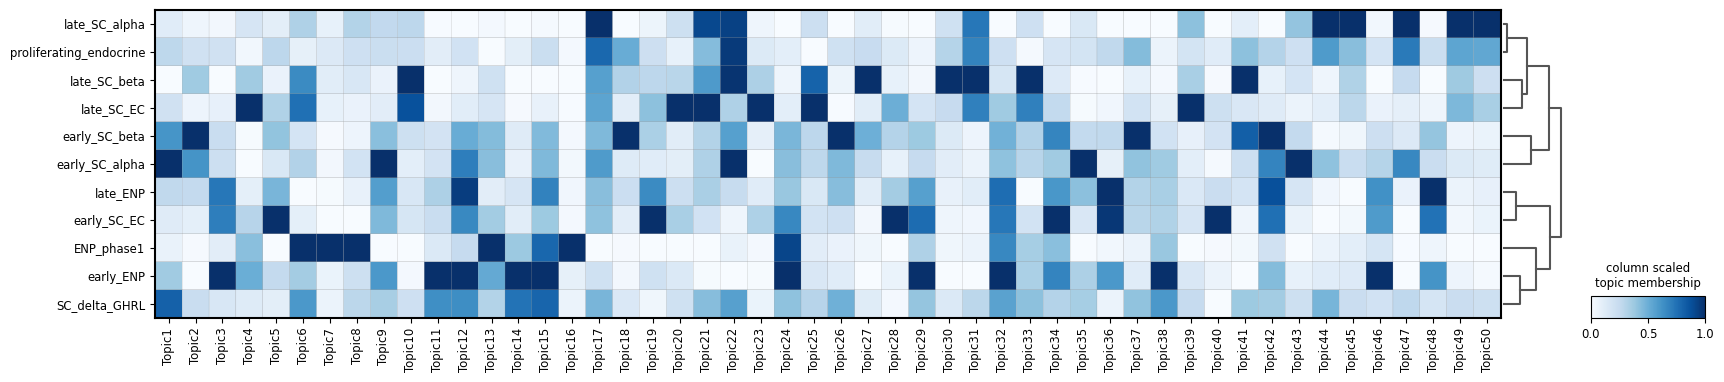

In [22]:
# Matrix plot — column-scaled topic membership
group_col = groupby_variable if groupby_variable else "leiden_0.5"
sc.pl.matrixplot(
    adata_topics,
    var_names=adata_topics.var_names,
    groupby=group_col,
    dendrogram=True,
    cmap="Blues",
    standard_scale="var",
    colorbar_title="column scaled\ntopic membership",
    figsize=(20, 4),
    save=False,
    show=False,
)
plt.savefig(
    os.path.join(output_dir, "matrixplot_scaled.pdf"),
    bbox_inches="tight", dpi=150,
)
plt.show()

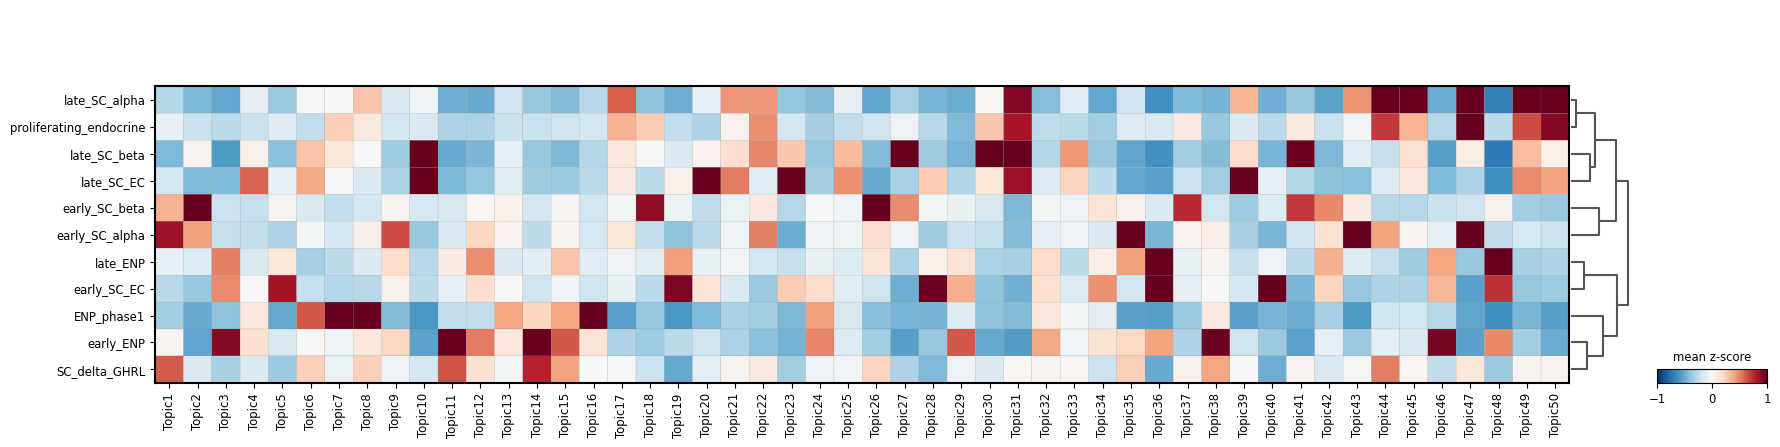

In [23]:
# Matrix plot — z-score
sc.pl.matrixplot(
    adata_topics,
    var_names=adata_topics.var_names,
    groupby=group_col,
    dendrogram=True,
    colorbar_title="mean z-score",
    layer="scaled",
    vmin=-1,
    vmax=1,
    cmap="RdBu_r",
    save=False,
    show=False,
)
plt.savefig(
    os.path.join(output_dir, "matrixplot_zscore.pdf"),
    bbox_inches="tight", dpi=150,
)
plt.show()

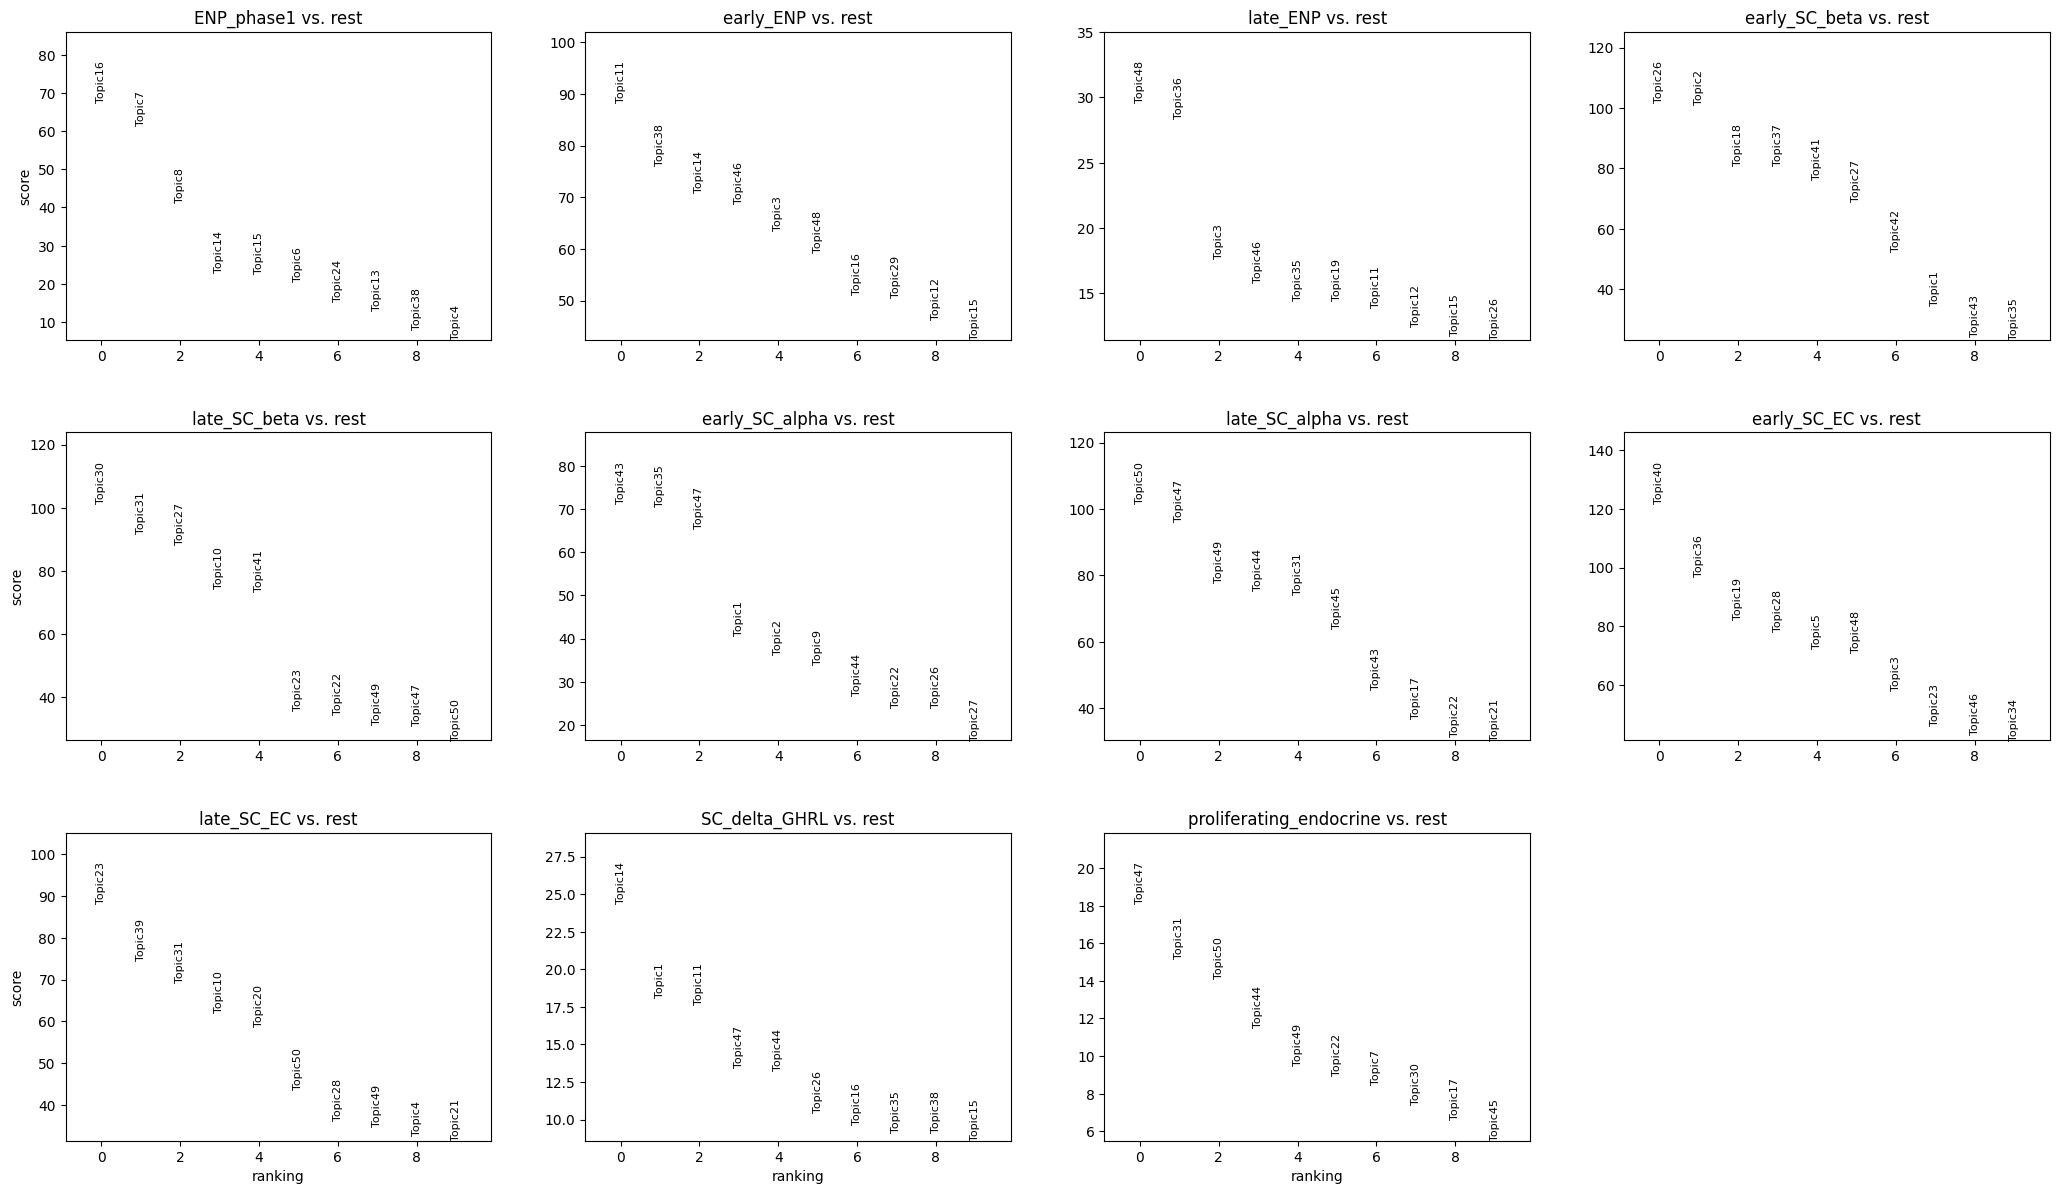

In [24]:
# Marker topic analysis
sc.tl.rank_genes_groups(adata_topics, groupby=group_col, method="wilcoxon", n_genes=10)
sc.pl.rank_genes_groups(adata_topics, n_genes=10, sharey=False, show=False)
plt.savefig(
    os.path.join(output_dir, "marker_topics.pdf"),
    bbox_inches="tight", dpi=150,
)
plt.show()

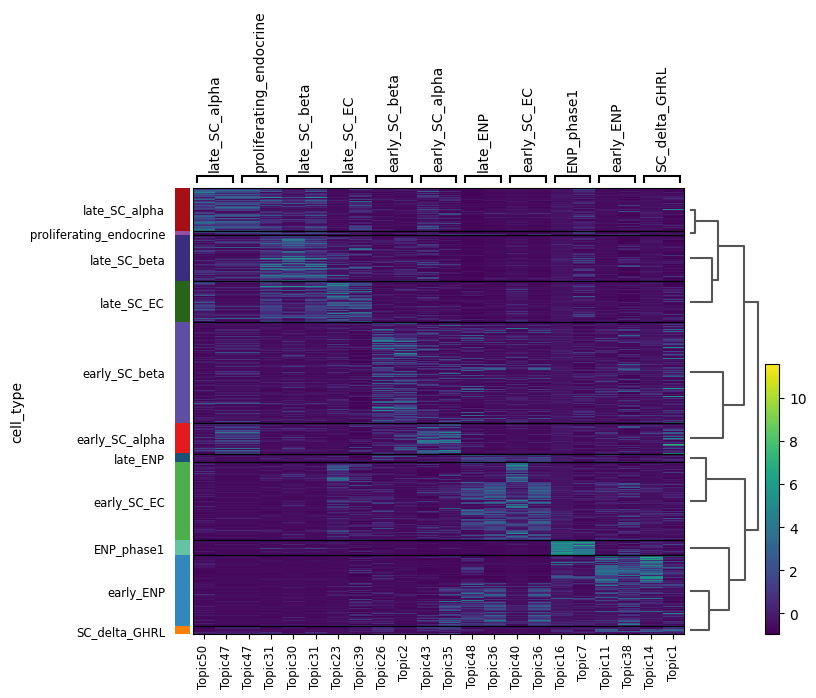

In [25]:
# Marker topics heatmap — top 2 topics per group
sc.pl.rank_genes_groups_heatmap(
    adata_topics,
    groupby=group_col,
    n_genes=2,
    use_raw=False,
    log=False,
    show_gene_labels=True,
    layer="scaled",
    cmap="viridis",
    show=False,
)
plt.savefig(
    os.path.join(output_dir, "marker_topics_heatmap.pdf"),
    bbox_inches="tight", dpi=150,
)
plt.show()

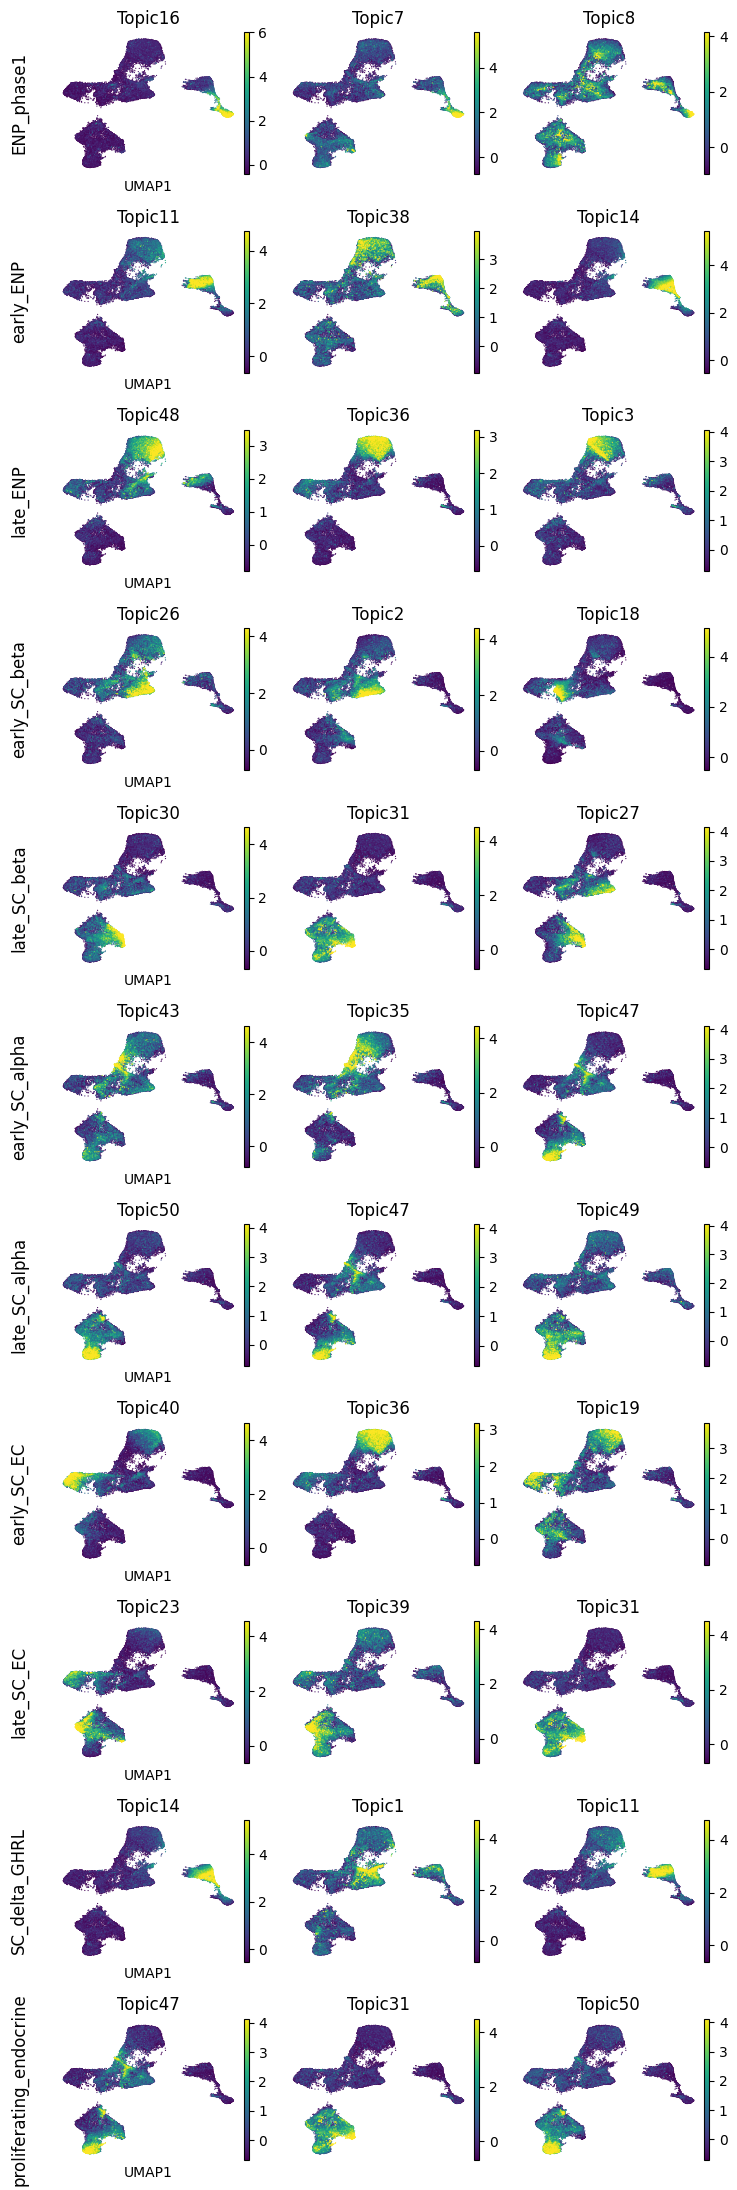

In [28]:
# Topic-specific UMAPs — top 3 marker topics per group
marker_topics = {}
for group in adata_topics.uns["rank_genes_groups"]["names"].dtype.names:
    marker_topics[group] = list(
        adata_topics.uns["rank_genes_groups"]["names"][group][:3]
    )

nrow = len(marker_topics)
ncol = max(len(vs) for vs in marker_topics.values())
fig, axs = plt.subplots(nrow, ncol, figsize=(2.5 * ncol, 2 * nrow))
if nrow == 1:
    axs = axs[None, :]

for row_idx, (group_name, markers) in enumerate(marker_topics.items()):
    for col_idx, marker in enumerate(markers):
        ax = axs[row_idx, col_idx]
        sc.pl.umap(
            adata_topics, color=marker, ax=ax, show=False, frameon=False,
            s=3, vmin="p5", vmax="p99.5", layer="scaled",
        )
        if col_idx == 0:
            ax.axis("on")
            ax.tick_params(
                top=False, bottom=False, left=False, right=False,
                labelleft=True, labelbottom=False,
            )
            ax.set_ylabel(group_name + "\n", rotation=90, fontsize=12)
            ax.set(frame_on=False)
    # Remove unused columns
    for col_idx in range(len(markers), ncol):
        axs[row_idx, col_idx].remove()

fig.tight_layout()
fig.savefig(
    os.path.join(output_dir, "marker_topic_umaps.pdf"),
    bbox_inches="tight", dpi=150,
)
plt.show()

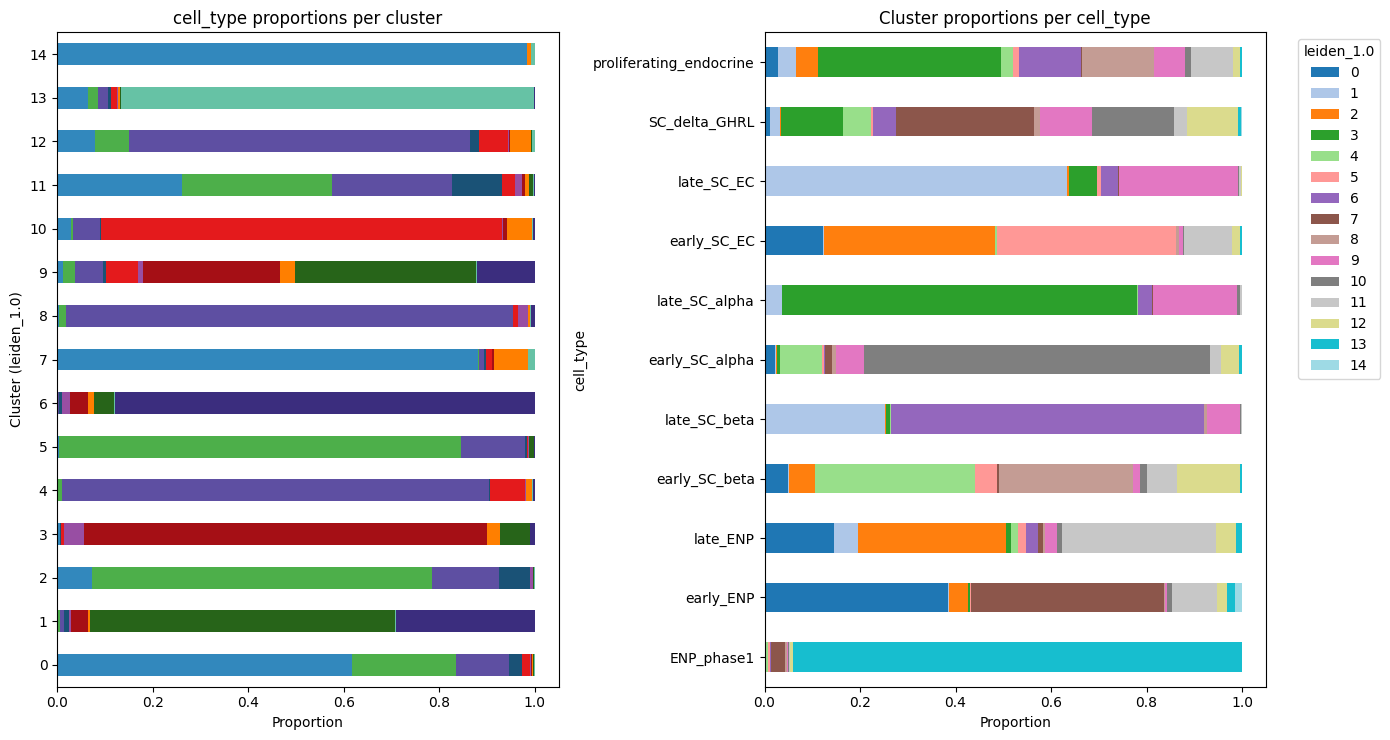

In [29]:
# Cluster composition barplots
if groupby_variable is not None:
    cluster_col = "leiden_1.0"
    clusters = sorted(adata_topics.obs[cluster_col].unique(), key=lambda x: int(x))

    # Proportion of each group within each cluster
    props = []
    for cluster in clusters:
        mask = adata_topics.obs[cluster_col] == cluster
        counts = adata_topics.obs.loc[mask, groupby_variable].value_counts(normalize=True)
        counts.name = cluster
        props.append(counts)
    props_df = pd.concat(props, axis=1).T.fillna(0)

    # Use group colors if available
    color_key = f"{groupby_variable}_colors"
    if group_colors is not None:
        bar_colors = [group_colors.get(c, "#999999") for c in props_df.columns]
    elif color_key in adata_topics.uns:
        cats = adata_topics.obs[groupby_variable].cat.categories
        color_map = dict(zip(cats, adata_topics.uns[color_key]))
        bar_colors = [color_map.get(c, "#999999") for c in props_df.columns]
    else:
        bar_colors = None

    fig, axes = plt.subplots(1, 2, figsize=(14, max(5, len(clusters) * 0.5)))

    # Left: group proportions per cluster
    props_df.plot.barh(stacked=True, ax=axes[0], color=bar_colors, legend=False)
    axes[0].set_xlabel("Proportion")
    axes[0].set_ylabel(f"Cluster ({cluster_col})")
    axes[0].set_title(f"{groupby_variable} proportions per cluster")

    # Right: cluster proportions per group
    props_inv = []
    groups = adata_topics.obs[groupby_variable].cat.categories if hasattr(
        adata_topics.obs[groupby_variable], "cat"
    ) else adata_topics.obs[groupby_variable].unique()
    for group in groups:
        mask = adata_topics.obs[groupby_variable] == group
        counts = adata_topics.obs.loc[mask, cluster_col].value_counts(normalize=True)
        counts.name = group
        props_inv.append(counts)
    props_inv_df = pd.concat(props_inv, axis=1).T.fillna(0)
    props_inv_df = props_inv_df[sorted(props_inv_df.columns, key=lambda x: int(x))]
    props_inv_df.plot.barh(stacked=True, ax=axes[1], cmap="tab20", legend=True)
    axes[1].set_xlabel("Proportion")
    axes[1].set_ylabel(groupby_variable)
    axes[1].set_title(f"Cluster proportions per {groupby_variable}")
    axes[1].legend(title=cluster_col, bbox_to_anchor=(1.05, 1), loc="upper left")

    plt.tight_layout()
    fig.savefig(
        os.path.join(output_dir, "cluster_composition_barplots.pdf"),
        bbox_inches="tight", dpi=150,
    )
    plt.show()
else:
    print("Set groupby_variable to generate cluster composition barplots.")

Generating cluster composition barplots for diff_batch...


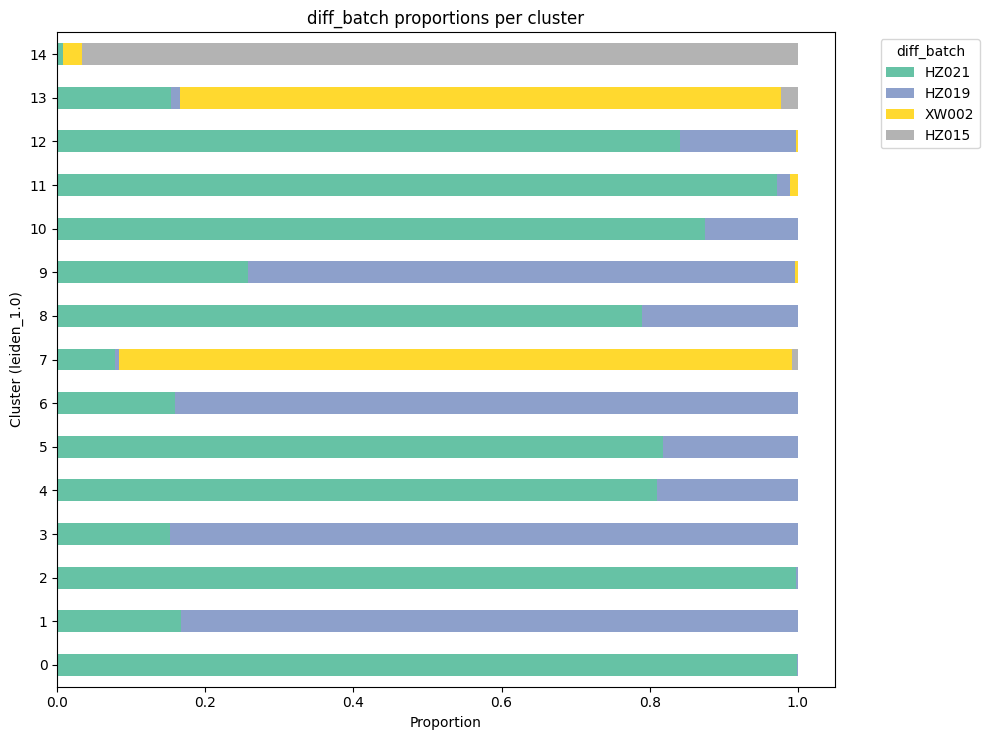

Generating cluster composition barplots for diff_stage...


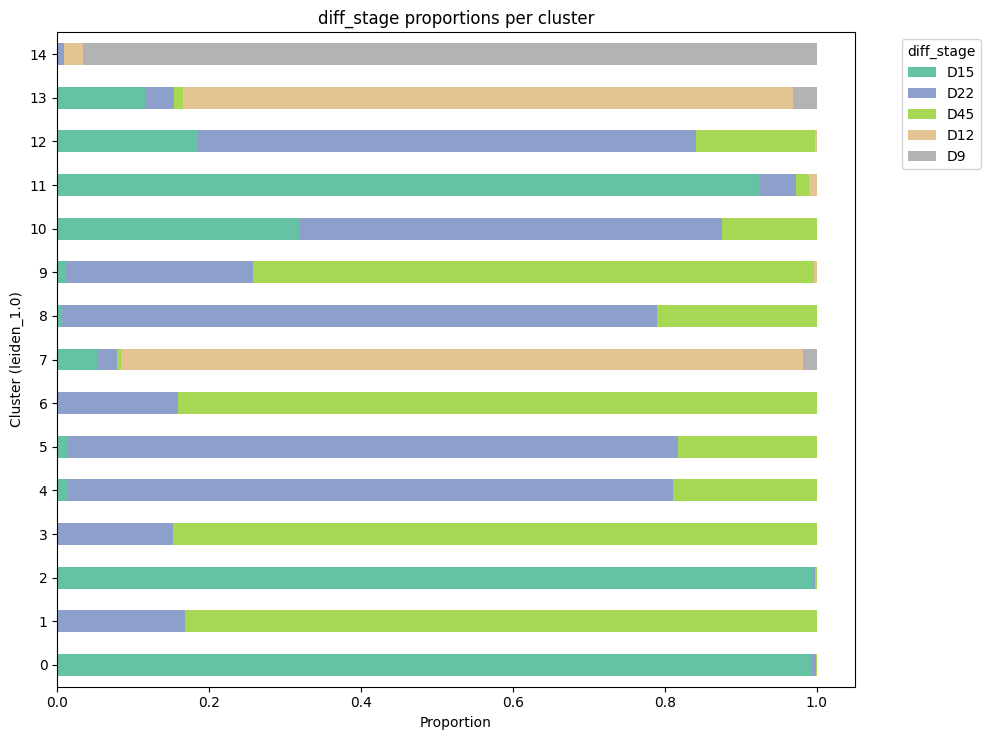

Generating cluster composition barplots for replicate...


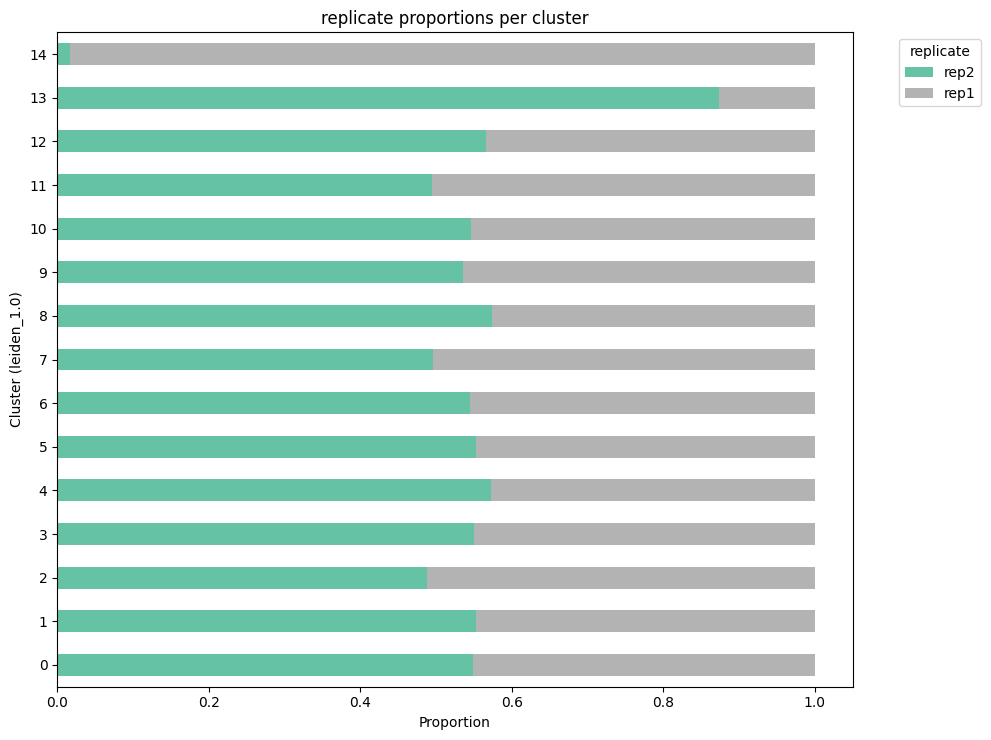

In [31]:
# Do the same for other plot vars
for var in ["diff_batch", "diff_stage", "replicate"]:
    if var in adata_topics.obs.columns:
        print(f"Generating cluster composition barplots for {var}...")
        cluster_col = "leiden_1.0"
        clusters = sorted(adata_topics.obs[cluster_col].unique(), key=lambda x: int(x))

        # Proportion of each group within each cluster
        props = []
        for cluster in clusters:
            mask = adata_topics.obs[cluster_col] == cluster
            counts = adata_topics.obs.loc[mask, var].value_counts(normalize=True)
            counts.name = cluster
            props.append(counts)
        props_df = pd.concat(props, axis=1).T.fillna(0)

        fig, ax = plt.subplots(figsize=(10, max(5, len(clusters) * 0.5)))
        props_df.plot.barh(stacked=True, ax=ax, cmap="Set2", legend=True)
        ax.set_xlabel("Proportion")
        ax.set_ylabel(f"Cluster ({cluster_col})")
        ax.set_title(f"{var} proportions per cluster")
        ax.legend(title=var, bbox_to_anchor=(1.05, 1), loc="upper left")

        plt.tight_layout()
        fig.savefig(
            os.path.join(output_dir, f"cluster_composition_{var}.pdf"),
            bbox_inches="tight", dpi=150,
        )
        plt.show()
    else:
        print(f"Variable '{var}' not found in cell metadata; skipping barplot.")

## 9. Save Final Objects

In [30]:
# Save cisTopic object with selected model
obj_path = os.path.join(output_dir, "cistopic_obj_with_model.pkl")
print(f"Saving cisTopic object to {obj_path}")
with open(obj_path, "wb") as f:
    pickle.dump(cistopic_obj, f)

# Save topic AnnData — ensure obs dtypes are h5ad-compatible
import numpy as np
adata_save = adata_topics.copy()
for col in adata_save.obs.columns:
    dtype = adata_save.obs[col].dtype
    if hasattr(dtype, "categories"):
        # Already categorical — h5ad handles these natively
        continue
    if dtype == object:
        adata_save.obs[col] = adata_save.obs[col].astype(str)

h5ad_path = os.path.join(output_dir, f"topics_{selected_n_topics}.h5ad")
print(f"Saving topic AnnData to {h5ad_path}")
adata_save.write_h5ad(h5ad_path)

print("\nAll outputs saved to:", output_dir)
for fname in sorted(os.listdir(output_dir)):
    fpath = os.path.join(output_dir, fname)
    if os.path.isfile(fpath):
        size_mb = os.path.getsize(fpath) / 1024 / 1024
        print(f"  {fname} ({size_mb:.1f} MB)")

Saving cisTopic object to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/evaluation/cistopic_obj_with_model.pkl


... storing 'cisTopic_nr_frag' as categorical
... storing 'cisTopic_log_nr_frag' as categorical
... storing 'cisTopic_nr_acc' as categorical


Saving topic AnnData to /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/evaluation/topics_50.h5ad


... storing 'cisTopic_log_nr_acc' as categorical



All outputs saved to: /cellar/users/aklie/data/datasets/sc-islet-differentiation_10X-Multiome/results/4_deeptopic/endocrine_replicate/evaluation
  cell_topic_heatmap.pdf (0.1 MB)
  cistopic_obj_with_model.pkl (4286.4 MB)
  cluster_composition_barplots.pdf (0.0 MB)
  evaluation_params.yaml (0.0 MB)
  marker_topic_umaps.pdf (23.0 MB)
  marker_topics.pdf (0.0 MB)
  marker_topics_heatmap.pdf (0.0 MB)
  matrixplot_scaled.pdf (0.0 MB)
  matrixplot_zscore.pdf (0.0 MB)
  model_evaluation_metrics.csv (0.0 MB)
  model_evaluation_metrics.pdf (0.0 MB)
  topics_50.h5ad (96.3 MB)
  umap_overview.pdf (4.4 MB)
  umap_per_topic_count.pdf (4.2 MB)


# DONE!

---